<a href="https://colab.research.google.com/github/imfaiyazkhan02-del/imfaiyazkhan02-del/blob/main/EDA_GDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')

In [ ]:
df=pd.read_csv('gdp_data.csv')
print('Shape :',df.shape)
df.head()

Shape : (960, 4)


,Country Name,Country Code,Year,Value
0,United States,USA,2000,10250000000000.00
1,United States,USA,2001,10730193770390.85
2,United States,USA,2002,11111990663401.93
3,United States,USA,2003,11514123122793.08
4,United States,USA,2004,12078230201031.46


In [ ]:
df.tail(10)

,Country Name,Country Code,Year,Value
950,Kenya,KEN,2014,24938114181.17
951,Kenya,KEN,2015,25957448577.47
952,Kenya,KEN,2016,27806344849.92
953,Kenya,KEN,2017,28950391075.97
954,Kenya,KEN,2018,30546239128.23
955,Kenya,KEN,2019,32291180438.80
956,Kenya,KEN,2020,32053208849.92
957,Kenya,KEN,2021,33849915233.88
958,Kenya,KEN,2022,36141706241.98
959,Kenya,KEN,2023,38736445662.96


In [ ]:
df.describe()

,Year,Value
count,960.00,960.00
mean,2011.50,1137658583030.25
std,6.93,2686942305968.51
min,2000.00,12000000000.00
25%,2005.75,167442664324.55
50%,2011.50,330245551637.90
75%,2017.25,911991204897.71
max,2023.00,22126519743605.92


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  960 non-null    object 
 1   Country Code  960 non-null    object 
 2   Year          960 non-null    int64  
 3   Value         960 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 30.1+ KB


In [ ]:
pd.options.display.float_format = '{:.2f}'.format
display(df.head())

,Country Name,Country Code,Year,Value
0,United States,USA,2000,10250000000000.00
1,United States,USA,2001,10730193770390.85
2,United States,USA,2002,11111990663401.93
3,United States,USA,2003,11514123122793.08
4,United States,USA,2004,12078230201031.46


In [ ]:
df['Value'] = df['Value'] / 1_000_000_000
print("Values in billions:")
display(df.head())

Values in billions:


,Country Name,Country Code,Year,Value
0,United States,USA,2000,10250.00
1,United States,USA,2001,10730.19
2,United States,USA,2002,11111.99
3,United States,USA,2003,11514.12
4,United States,USA,2004,12078.23


In [ ]:
print(df.describe())

         Year      GDP
count  960.00   960.00
mean  2011.50  1137.66
std      6.93  2686.94
min   2000.00    12.00
25%   2005.75   167.44
50%   2011.50   330.25
75%   2017.25   911.99
max   2023.00 22126.52


In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  960 non-null    object 
 1   Code          960 non-null    object 
 2   Year          960 non-null    int64  
 3   GDP           960 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 30.1+ KB
Country Name    0
Code            0
Year            0
GDP             0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['GDP Growth Rate'] = df.groupby('Code')['GDP'].pct_change() * 100
display(df.head())

,Country Name,Code,Year,GDP,GDP Growth Rate
0,United States,USA,2000,10250.00,NaN
1,United States,USA,2001,10730.19,4.68
2,United States,USA,2002,11111.99,3.56
3,United States,USA,2003,11514.12,3.62
4,United States,USA,2004,12078.23,4.90


In [ ]:
df.dropna(inplace=True)
print('Shape after dropping NaN values:', df.shape)
display(df.head())

Shape after dropping NaN values: (920, 5)


,Country Name,Code,Year,GDP,GDP Growth Rate
1,United States,USA,2001,10730.19,4.68
2,United States,USA,2002,11111.99,3.56
3,United States,USA,2003,11514.12,3.62
4,United States,USA,2004,12078.23,4.90
5,United States,USA,2005,12705.38,5.19


In [ ]:
df.columns

Index(['Country Name', 'Code', 'Year', 'GDP', 'GDP Growth Rate'], dtype='object')

In [ ]:
print(df['Country Name'].unique())

['United States' 'China' 'Japan' 'Germany' 'India' 'United Kingdom'
 'France' 'Italy' 'Brazil' 'Canada' 'Russia' 'South Korea' 'Australia'
 'Mexico' 'Spain' 'Indonesia' 'Saudi Arabia' 'Netherlands' 'Turkey'
 'Switzerland' 'Poland' 'Sweden' 'Belgium' 'Argentina' 'Norway' 'Nigeria'
 'South Africa' 'Thailand' 'Egypt' 'Bangladesh' 'Vietnam' 'Pakistan'
 'Philippines' 'Malaysia' 'Colombia' 'Chile' 'Israel' 'Ireland'
 'Singapore' 'Kenya']


In [ ]:
latest_year_gdp = df.loc[df.groupby('Code')['Year'].idxmax()]

In [ ]:
top_gdp_countries = latest_year_gdp.sort_values(by='GDP', ascending=False).head(10)

fig = px.bar(
    top_gdp_countries,
    x='GDP',
    y='Country Name',
    orientation='h',
    title='Top 10 Countries by Latest GDP (in Billions USD)',
    labels={'GDP': 'GDP (Billions USD)', 'Country Name': 'Country'},
    color='GDP',
    color_continuous_scale=px.colors.sequential.Plasma
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
median_growth_rate = df.groupby('Country Name')['GDP Growth Rate'].median().reset_index()
top_10_growth = median_growth_rate.sort_values(by='GDP Growth Rate', ascending=False).head(10)
display(top_10_growth)

,Country Name,GDP Growth Rate
7,China,9.35
12,India,7.29
39,Vietnam,6.85
22,Nigeria,6.12
2,Bangladesh,5.90
14,Ireland,5.89
13,Indonesia,5.86
18,Kenya,5.52
27,Russia,5.31
29,Singapore,4.80


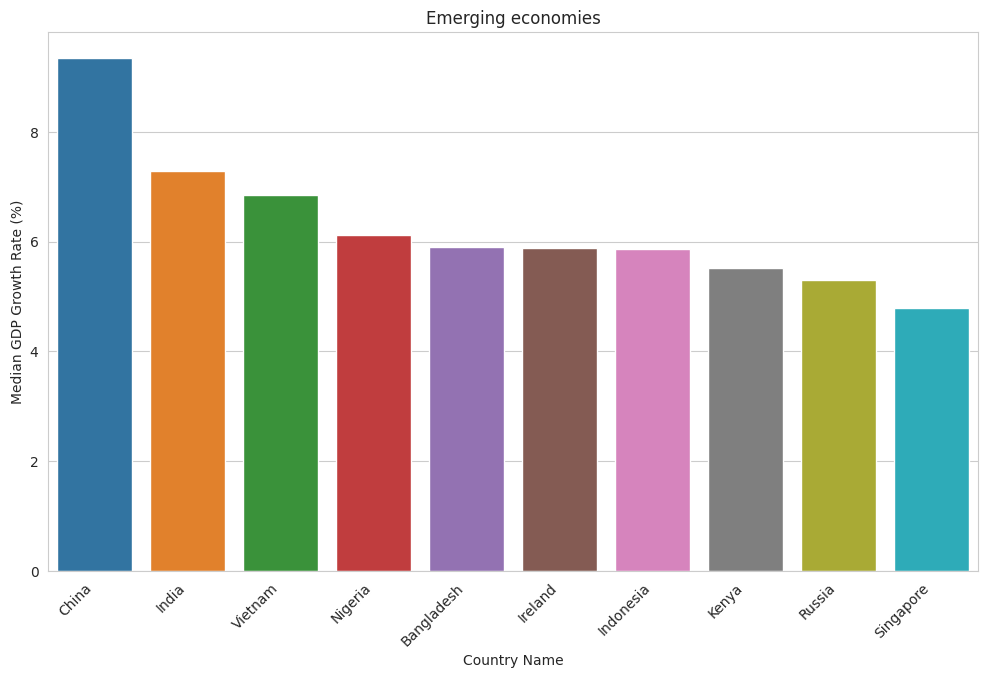

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Country Name', y='GDP Growth Rate', data=top_10_growth, hue='Country Name', legend=False)
plt.title('Emerging economies')
plt.xlabel('Country Name')
plt.ylabel('Median GDP Growth Rate (%)')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.show()

### GDP Growth Rate Correlation Heatmap

To explore how dependent the GDP growth of countries are on each other, we'll calculate the correlation matrix of their annual GDP growth rates and visualize it using a heatmap. A positive correlation indicates that countries' GDP growth tends to move in the same direction, while a negative correlation suggests an inverse relationship.

In [ ]:
# Pivot the DataFrame to get 'GDP Growth Rate' for each country over the years
gdp_growth_pivot = df.pivot_table(index='Year', columns='Country Name', values='GDP Growth Rate')

# Calculate the correlation matrix of GDP growth rates
gdp_growth_corr = gdp_growth_pivot.corr()

# Display the head of the correlation matrix
print("GDP Growth Rate Correlation Matrix (first 5x5):")
display(gdp_growth_corr.head())


GDP Growth Rate Correlation Matrix (first 5x5):


Country Name,Argentina,Australia,Bangladesh,Belgium,Brazil,Canada,Chile,China,Colombia,Egypt,...,South Africa,South Korea,Spain,Sweden,Switzerland,Thailand,Turkey,United Kingdom,United States,Vietnam
Country Name,,,,,,,,,,,,,,,,,,,,,
Argentina,1.00,0.43,0.50,0.51,0.19,0.50,0.51,0.66,0.42,0.60,...,0.63,0.64,0.60,0.64,0.48,0.65,0.44,0.54,0.54,0.42
Australia,0.43,1.00,0.47,0.28,0.35,0.65,0.34,0.59,0.61,0.48,...,0.54,0.37,0.49,0.59,0.59,0.46,0.58,0.42,0.20,0.38
Bangladesh,0.50,0.47,1.00,0.71,0.35,0.73,0.54,0.90,0.76,0.48,...,0.78,0.70,0.55,0.73,0.56,0.61,0.49,0.42,0.44,0.51
Belgium,0.51,0.28,0.71,1.00,0.24,0.61,0.48,0.67,0.59,0.53,...,0.56,0.75,0.51,0.55,0.60,0.74,0.36,0.53,0.58,0.37
Brazil,0.19,0.35,0.35,0.24,1.00,0.43,0.61,0.39,0.47,0.54,...,0.39,0.48,0.49,0.49,0.55,0.19,0.58,0.10,0.60,0.21


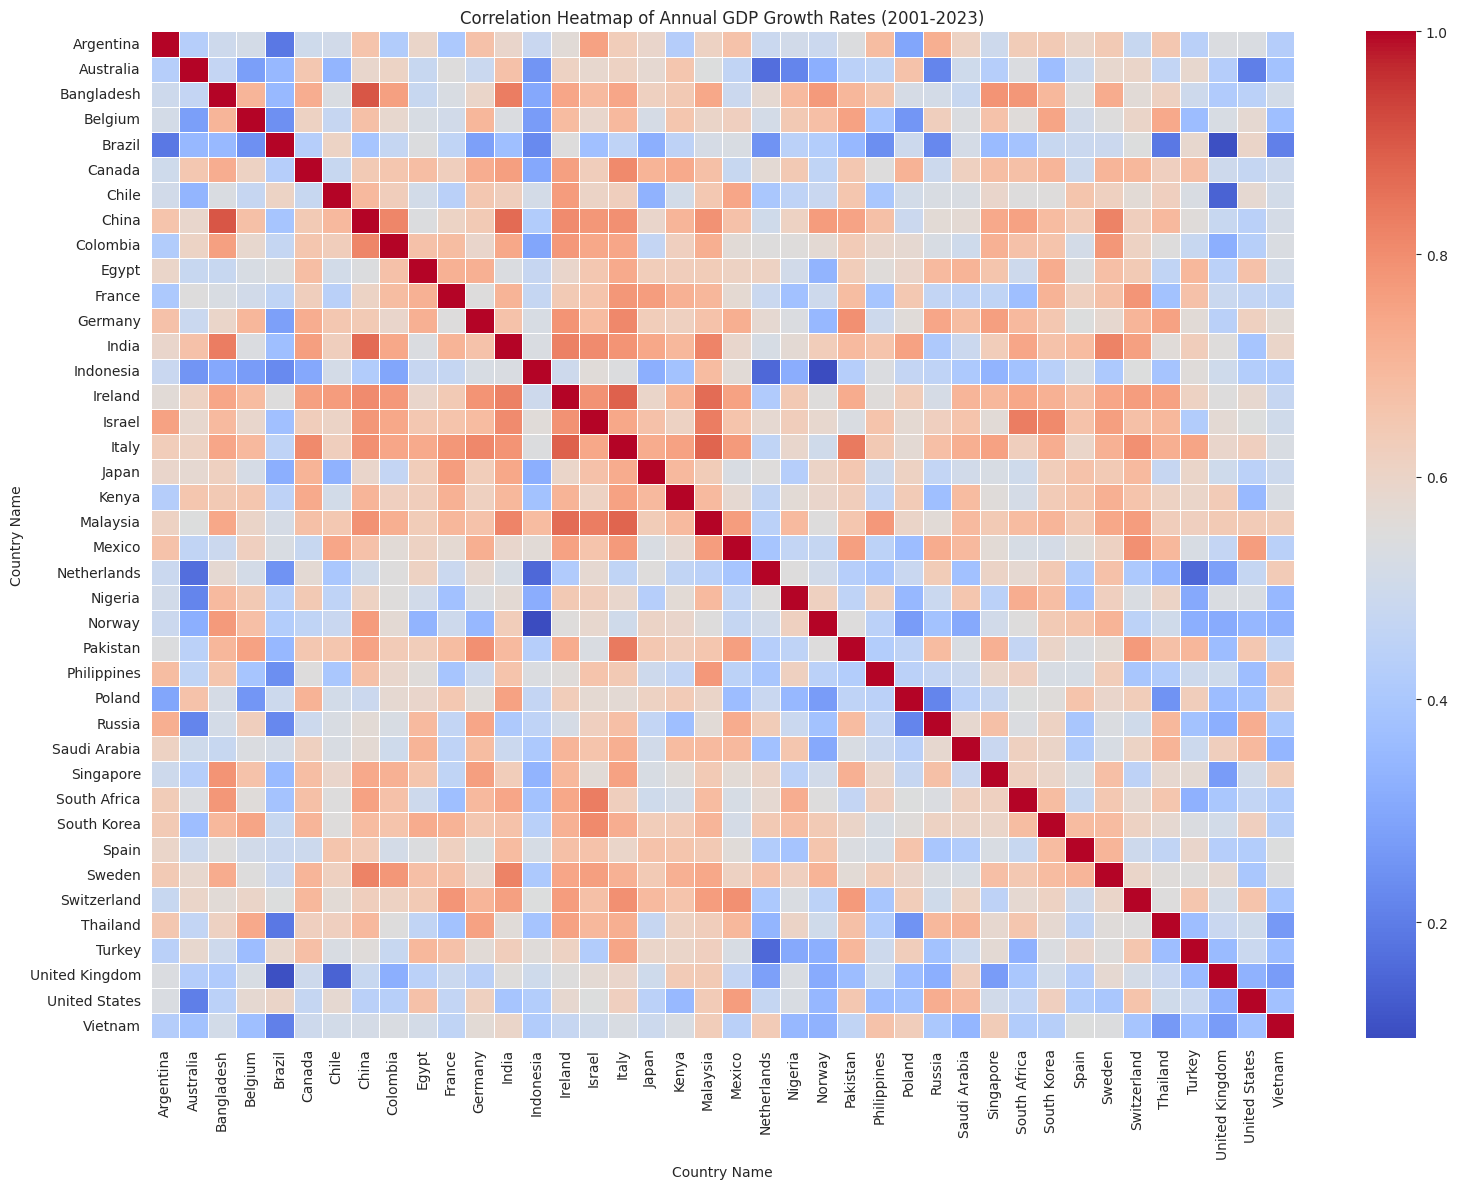

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(gdp_growth_corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Annual GDP Growth Rates (2001-2023)')
plt.xlabel('Country Name')
plt.ylabel('Country Name')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Individual Country Time Series Analysis

Let's visualize the GDP over time for a few selected countries to observe their individual growth trajectories.

### Comparing GDP Trends: Developed vs. Developing Countries

To understand the differences in economic growth, let's categorize a few countries into 'Developed' and 'Developing' groups and compare their aggregated GDP trends over time.

In [ ]:
# Define lists for developed and developing countries from the dataset
developed_countries = [
    'United States', 'Japan', 'Germany', 'United Kingdom', 'France',
    'Italy', 'Canada', 'Australia', 'South Korea', 'Spain',
    'Netherlands', 'Switzerland', 'Sweden', 'Belgium', 'Ireland', 'Singapore'
]
developing_countries = [
    'China', 'India', 'Brazil', 'Russia', 'Mexico', 'Indonesia',
    'Saudi Arabia', 'Turkey', 'Poland', 'Argentina', 'Nigeria',
    'South Africa', 'Thailand', 'Egypt', 'Bangladesh', 'Vietnam',
    'Pakistan', 'Philippines', 'Malaysia', 'Colombia', 'Chile', 'Israel', 'Kenya'
]

# Create a 'Group' column in the DataFrame
def assign_country_group(country_name):
    if country_name in developed_countries:
        return 'Developed'
    elif country_name in developing_countries:
        return 'Developing'
    else:
        return 'Other' # For countries not explicitly listed

df['Group'] = df['Country Name'].apply(assign_country_group)

# Filter out 'Other' if it's not needed for the comparison
df_filtered_groups = df[df['Group'] != 'Other']

# Aggregate GDP by Year and Group
gdp_by_group = df_filtered_groups.groupby(['Year', 'Group'])['GDP'].sum().reset_index()

# Display the aggregated data
print("Aggregated GDP by Group (first 5 rows):")
display(gdp_by_group.head())


Aggregated GDP by Group (first 5 rows):


,Year,Group,GDP
0,2001,Developed,25644.79
1,2001,Developing,5721.07
2,2002,Developed,26301.59
3,2002,Developing,6049.10
4,2003,Developed,27072.89


In [ ]:
# Create an interactive line plot for GDP trends by group
fig = px.line(
    gdp_by_group,
    x='Year',
    y='GDP',
    color='Group',
    title='GDP Trends: Developed vs. Developing Countries (in Billions USD)',
    labels={'GDP': 'Total GDP (Billions USD)', 'Year': 'Year'},
    hover_data={'Group': True, 'Year': True, 'GDP': ':.2f'}
)

fig.update_layout(hovermode='x unified')
fig.show()


In [ ]:
# Select a few countries for individual time series analysis
selected_countries = ['United States', 'China', 'India']
individual_gdp_df = df[df['Country Name'].isin(selected_countries)]

# Create an interactive line plot for GDP over time for selected countries
fig = px.line(
    individual_gdp_df,
    x='Year',
    y='GDP',
    color='Country Name',
    title='GDP Over Time for Selected Countries (in Billions USD)',
    labels={'GDP': 'GDP (Billions USD)', 'Year': 'Year'},
    hover_data={'Country Name': True, 'Year': True, 'GDP': ':.2f'}
)

fig.update_layout(hovermode='x unified')
fig.show()

### Growth Rate Over Time for Selected Countries

In [ ]:
# Select a few countries for individual GDP Growth Rate time series analysis
selected_countries = ['United States', 'China', 'India']
individual_gdp_growth_df = df[df['Country Name'].isin(selected_countries)]

# Create an interactive line plot for GDP Growth Rate over time for selected countries
fig = px.line(
    individual_gdp_growth_df,
    x='Year',
    y='GDP Growth Rate',
    color='Country Name',
    title='GDP Growth Rate Over Time for Selected Countries',
    labels={'GDP Growth Rate': 'GDP Growth Rate (%)', 'Year': 'Year'},
    hover_data={'Country Name': True, 'Year': True, 'GDP Growth Rate': ':.2f'}
)

fig.update_layout(hovermode='x unified')
fig.show()


### Distribution of GDP Growth Rate

In [ ]:
# Create a histogram to visualize the distribution of GDP Growth Rate
fig = px.histogram(
    df,
    x='GDP Growth Rate',
    nbins=50, # Number of bins for the histogram
    title='Distribution of GDP Growth Rate Across All Countries',
    labels={'GDP Growth Rate': 'GDP Growth Rate (%)'},
    marginal='box' # Add a box plot to show statistical summary
)

fig.update_layout(bargap=0.1) # Add some gap between bars for better readability
fig.show()


### GDP vs. GDP Growth Rate in 2023

In [ ]:
# Filter data for the year 2023
df_2023 = df[df['Year'] == 2023]

# Create a scatter plot
fig = px.scatter(
    df_2023,
    x='GDP',
    y='GDP Growth Rate',
    color='Country Name',
    size='GDP', # Size of markers based on GDP
    hover_name='Country Name',
    title='GDP vs. GDP Growth Rate in 2023',
    labels={'GDP': 'GDP (Billions USD)', 'GDP Growth Rate': 'GDP Growth Rate (%)'},
    log_x=True, # Use a log scale for GDP due to wide range of values
    template='plotly_white' # Use a clean template
)

fig.update_layout(
    hovermode='closest',
    xaxis_title='GDP (Billions USD, Log Scale)',
    yaxis_title='GDP Growth Rate (%)'
)
fig.show()


In [ ]:
# Calculate the correlation between GDP and GDP Growth Rate for 2023
correlation = df_2023['GDP'].corr(df_2023['GDP Growth Rate'])

print(f"Correlation between GDP and GDP Growth Rate in 2023: {correlation:.2f}")


Correlation between GDP and GDP Growth Rate in 2023: -0.06
